1. identify a suitable preprocessing
2. identify the best scales for tracking the blood vessels in the brain
3. use vesselness filters (or develop your own based on the Hessian, or anisotropy of the structure tensor)
4. apply local thickness on the obtained segmentations
5. color-code the segmentations based on their local thickness and show the results in 3D
6. report statistics on the diameter of the vessels you segmented

In [1]:
# PART 0, data reading
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img_mri = nib.load('./MRI_Brain_T1mprage_1.nii') #MRI SCAN
img_seg = nib.load('./Segmentation2.nii')        #MANUAL SEGMENTATION CEREBELLUM

vol_mri = img_mri.get_fdata()  # data extracted
vol_seg = img_seg.get_fdata() # data manually segmented cerebellum, with ITK-SNAP

OPERATIONS TO PROCESS MANUAL SEGMENTATION

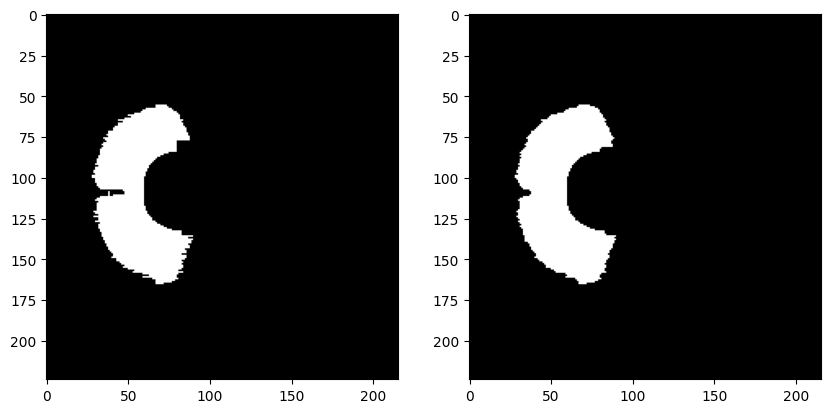

In [2]:
from skimage.morphology import remove_small_objects
from skimage.morphology import binary_closing
from skimage.morphology import remove_small_holes
from skimage.morphology import binary_dilation

vol_binary = vol_seg>0

vol_binary = remove_small_objects(vol_binary, min_size=5000,connectivity=1)

vol_binary = binary_closing(vol_binary)

vol_binary = remove_small_holes(vol_binary,1000,connectivity=1)


# example of 1 slice printed
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(vol_seg[:,:,130], cmap='gray')
ax[1].imshow(vol_binary[:,:,130], cmap='gray')
plt.show()


LABLES

In [3]:
from skimage.measure import label
# NOW LABLE THE SLICES 
labeled,num = label(vol_binary,background=0,return_num=True,connectivity=1)
# there is only one label
# which slices has cerebellum?
slices_with_cerebellum = []
for z in range(labeled.shape[2]):
    sl = labeled[:, :, z]
    if sl.sum() == 0:
        continue
    else:
        slices_with_cerebellum.append(z)
print("There are ",num," labels.")
print("The slices with cerebellum are:")
print(slices_with_cerebellum)

There are  1  labels.
The slices with cerebellum are:
[106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162]


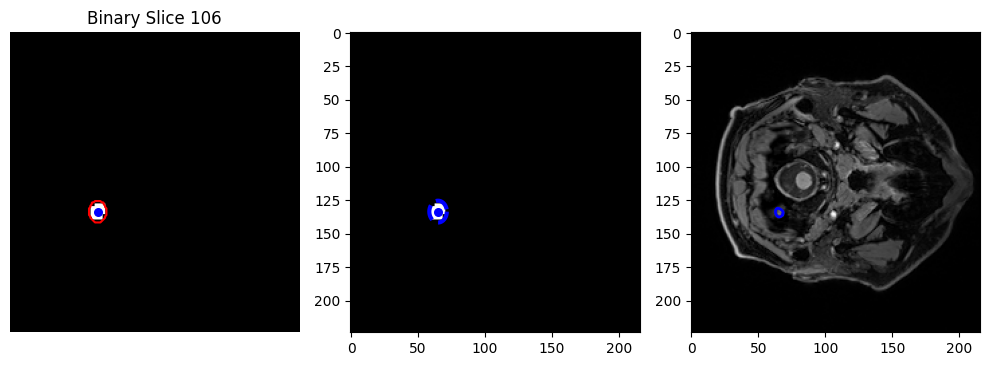

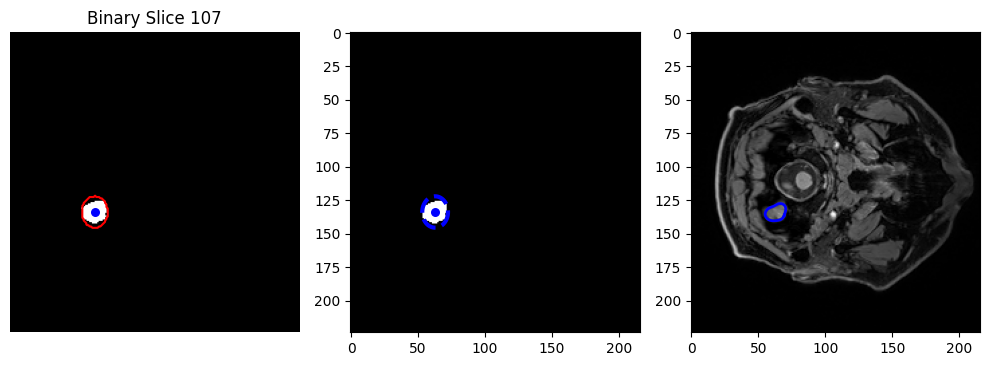

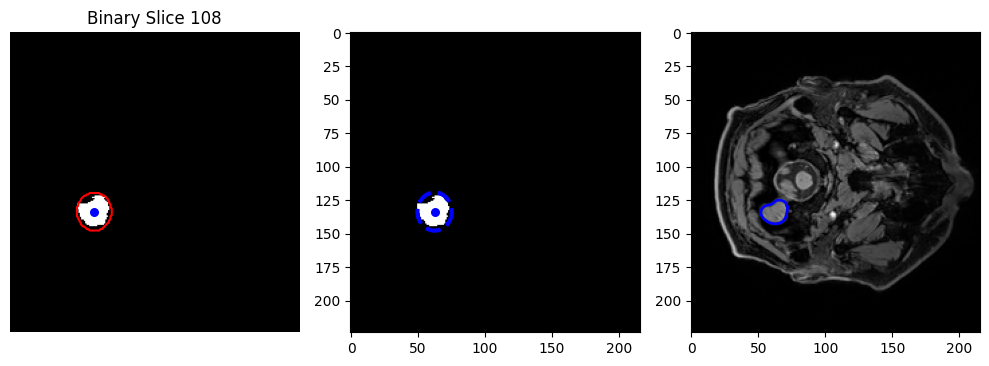

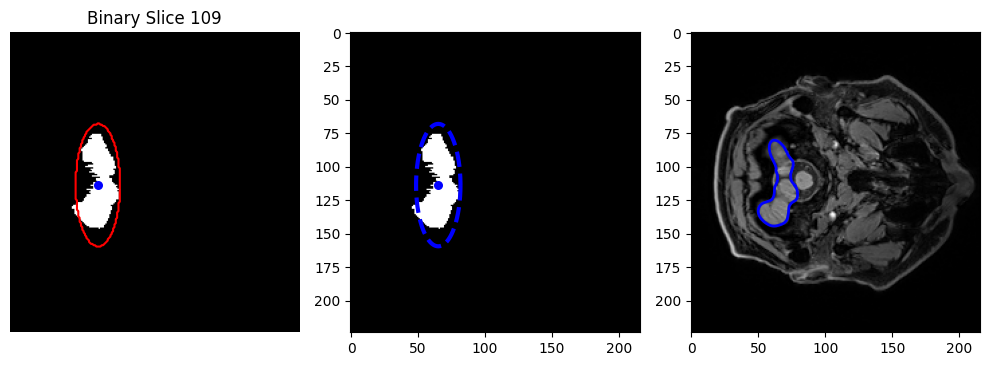

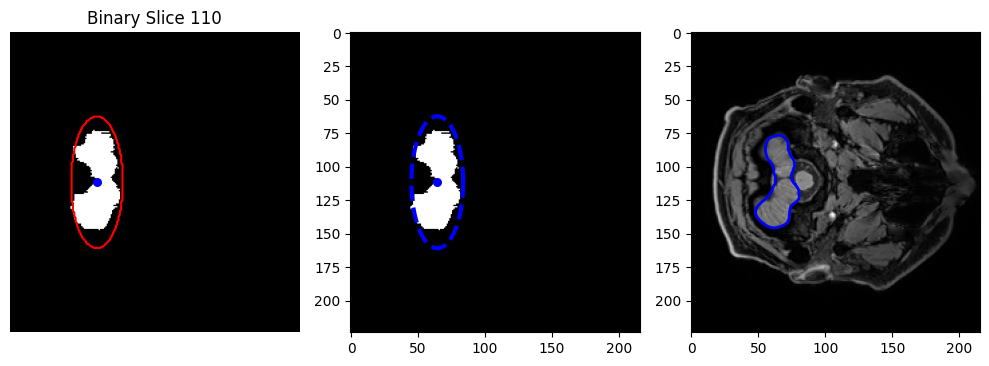

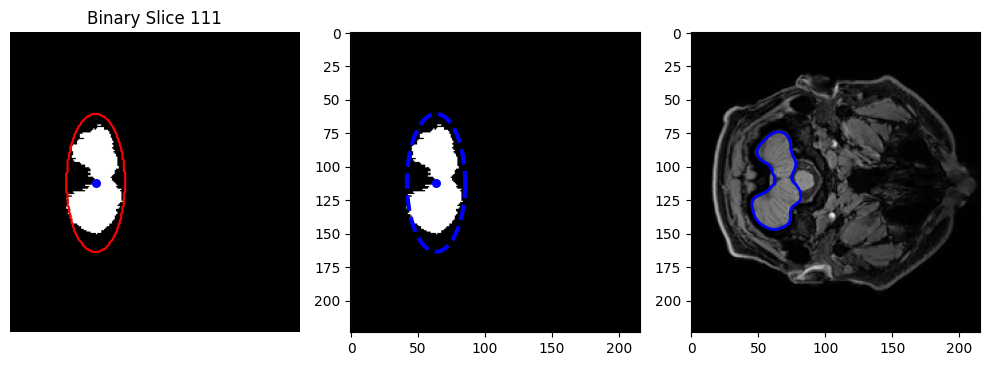

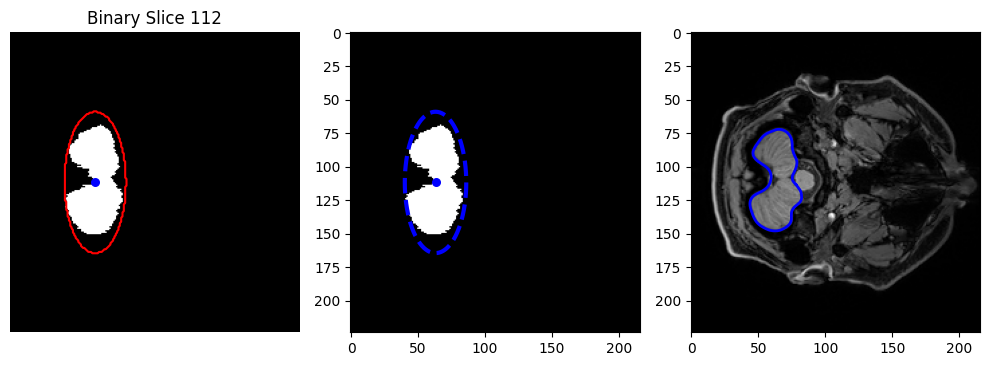

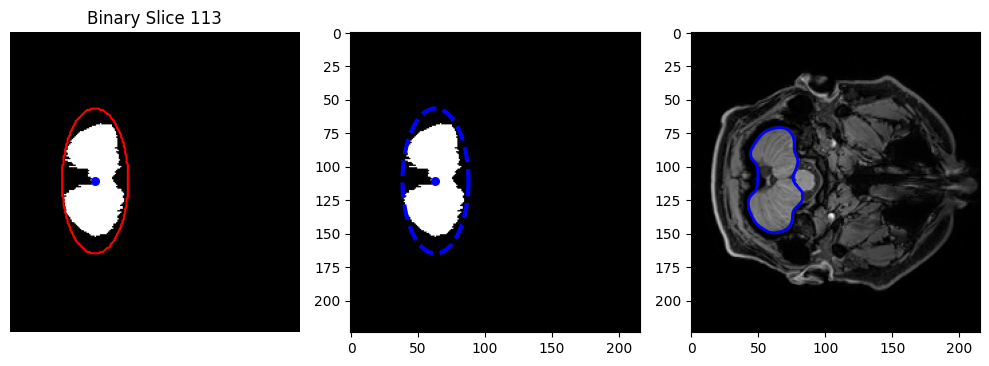

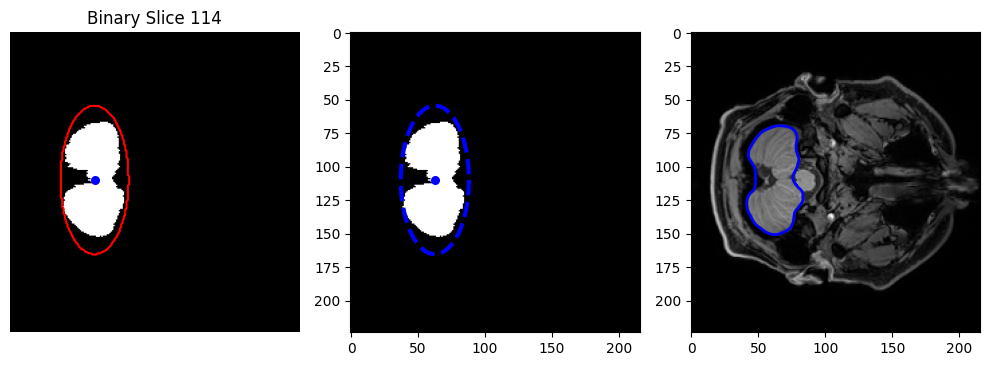

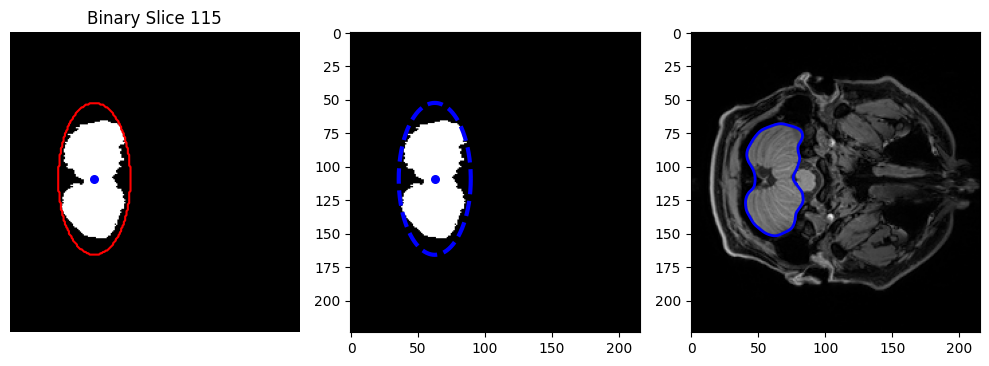

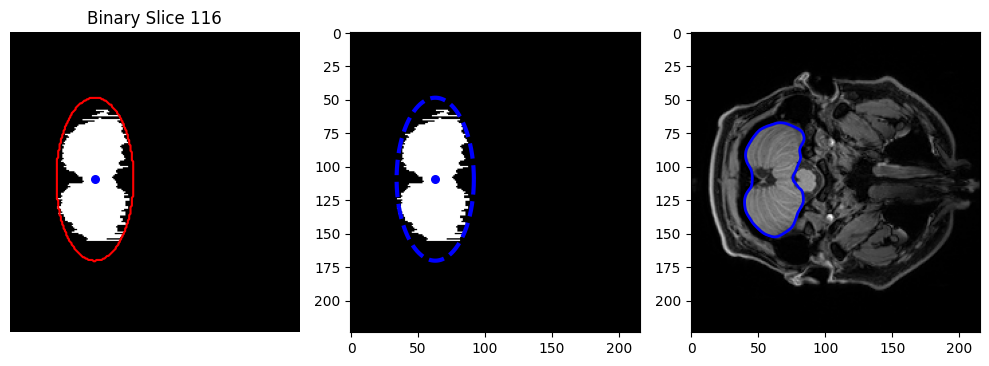

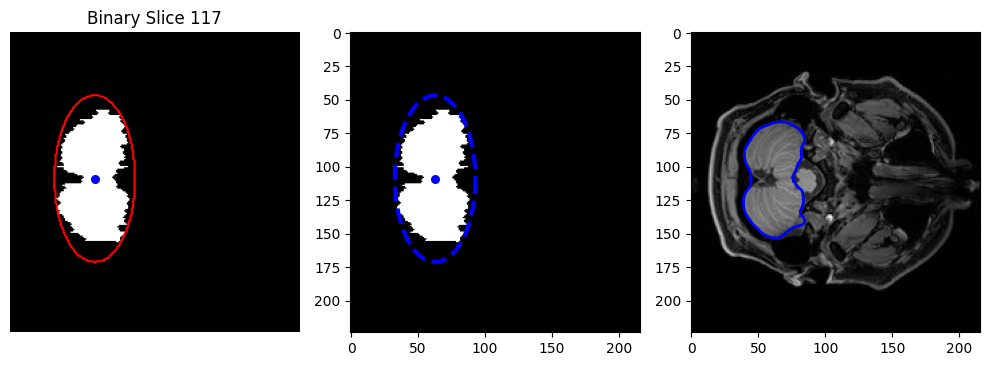

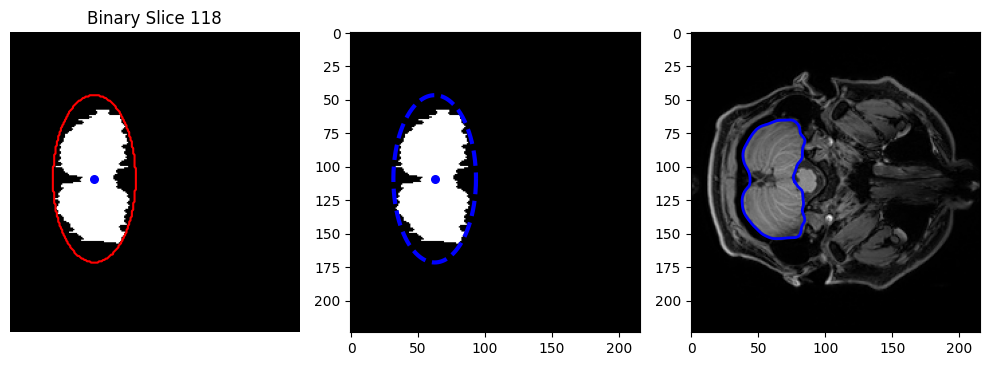

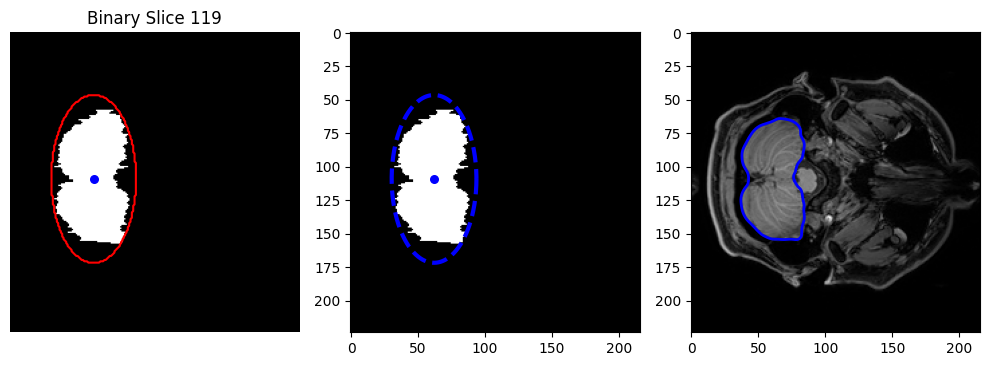

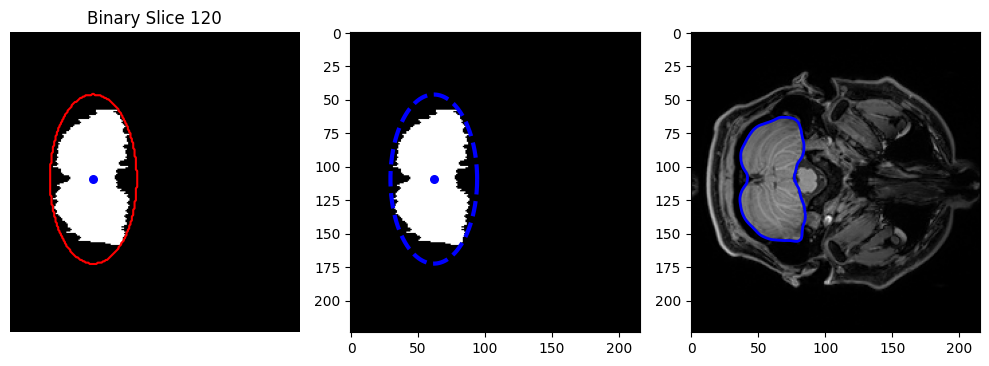

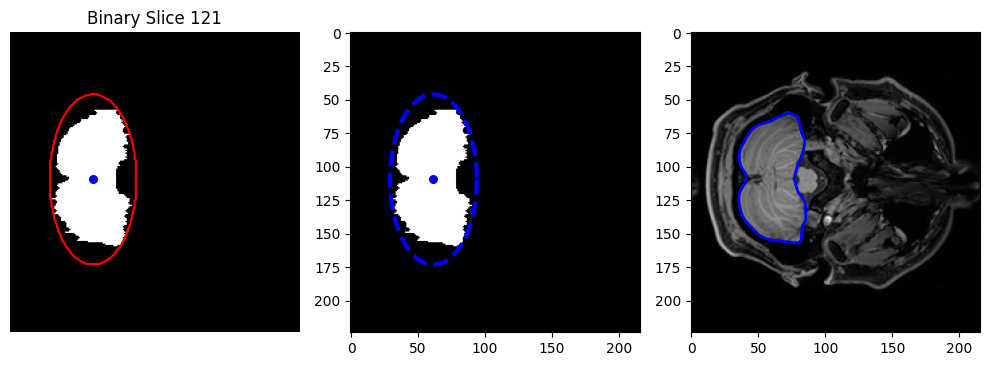

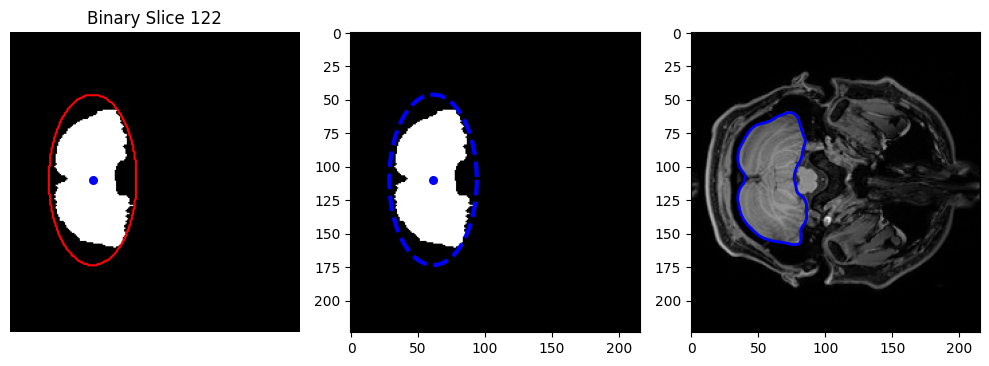

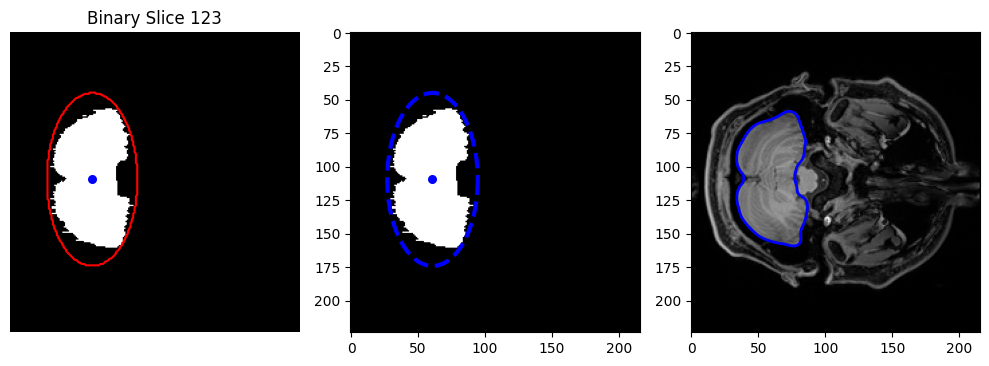

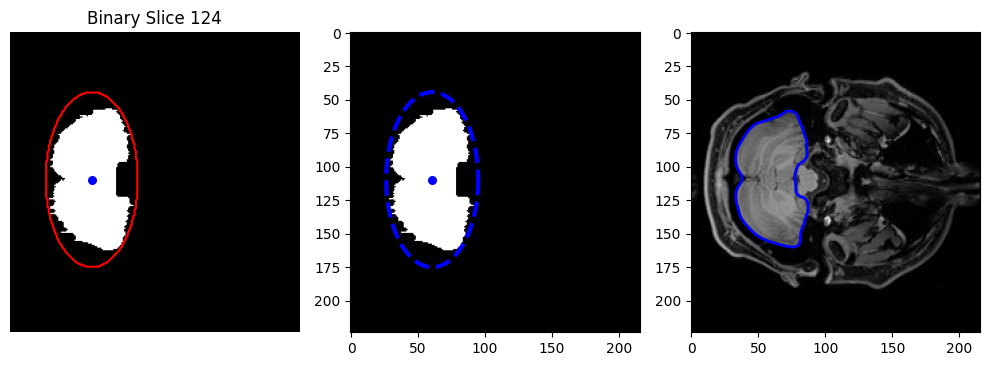

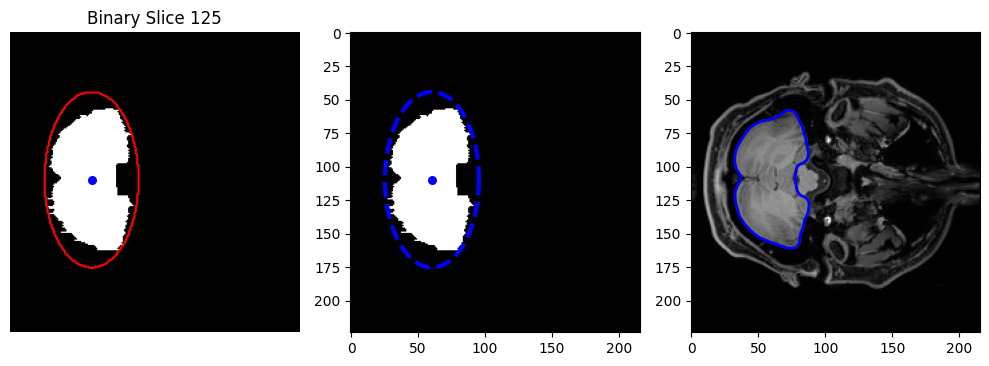

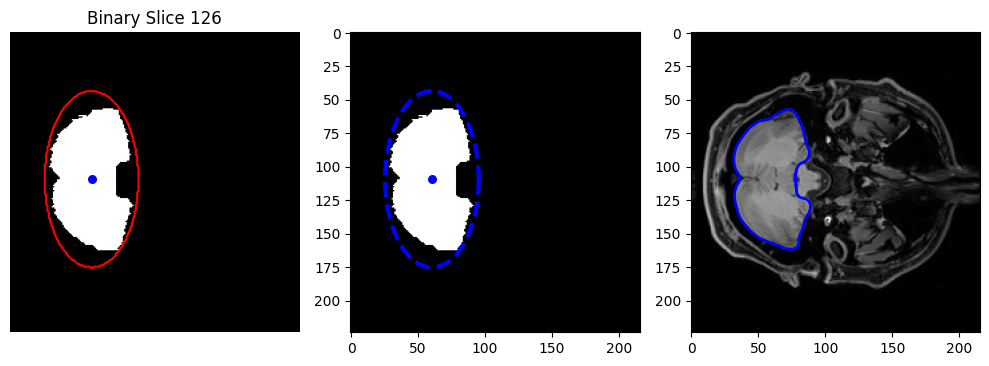

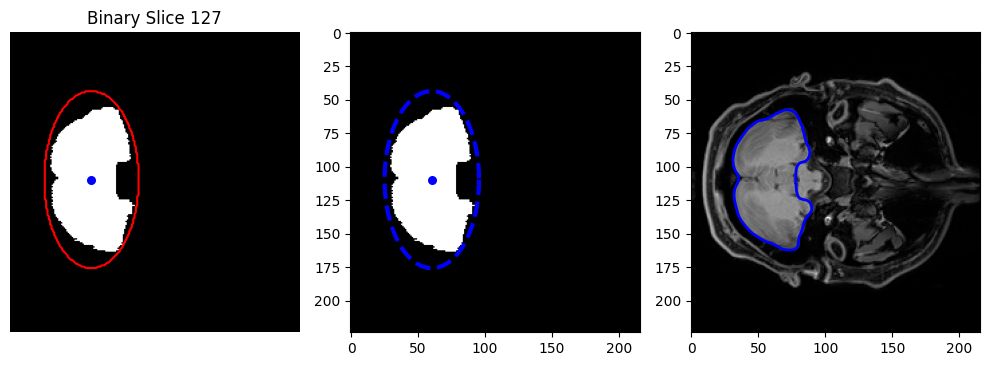

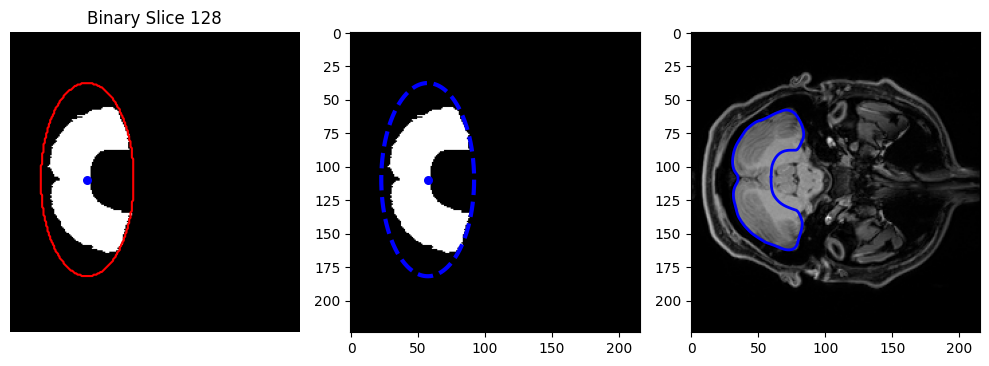

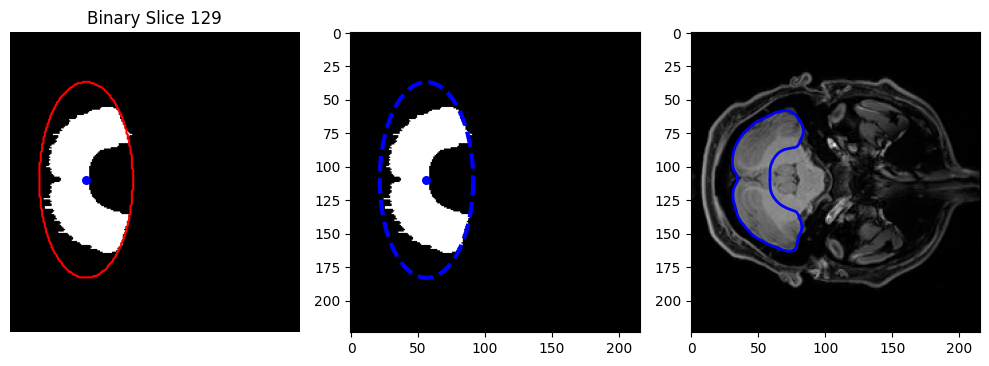

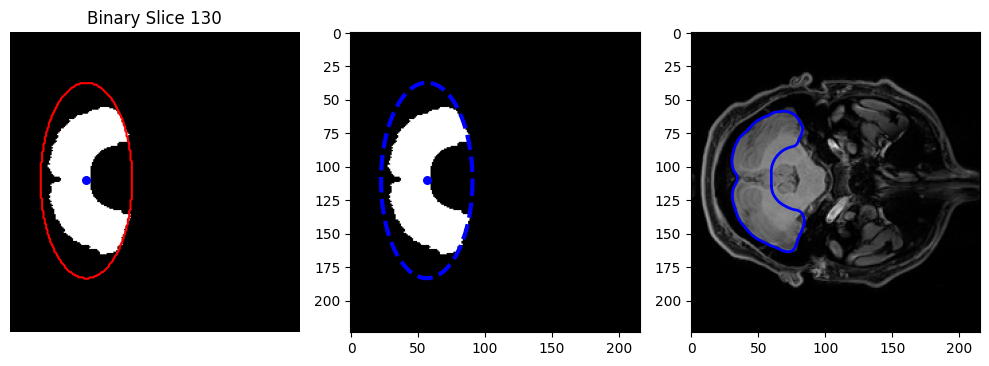

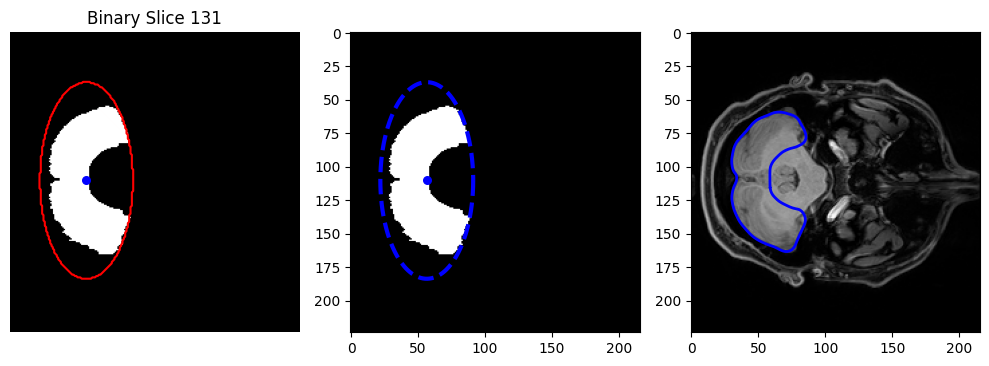

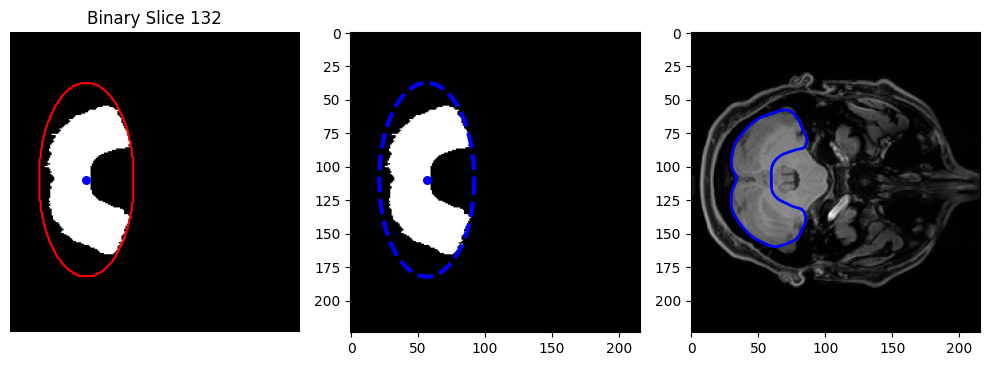

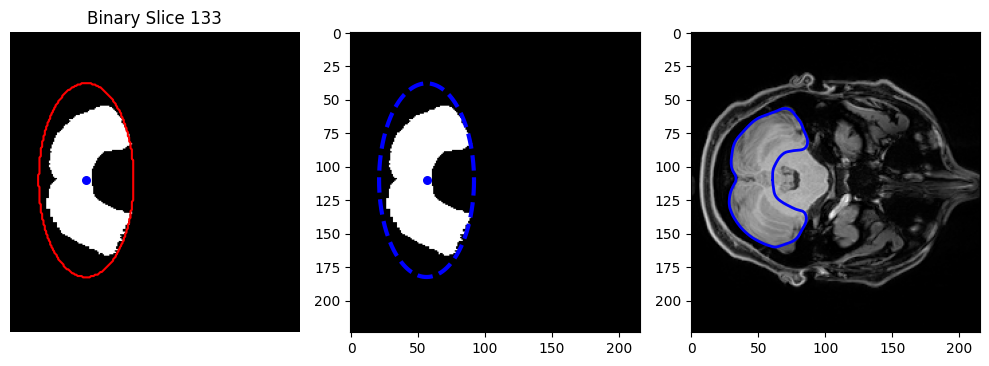

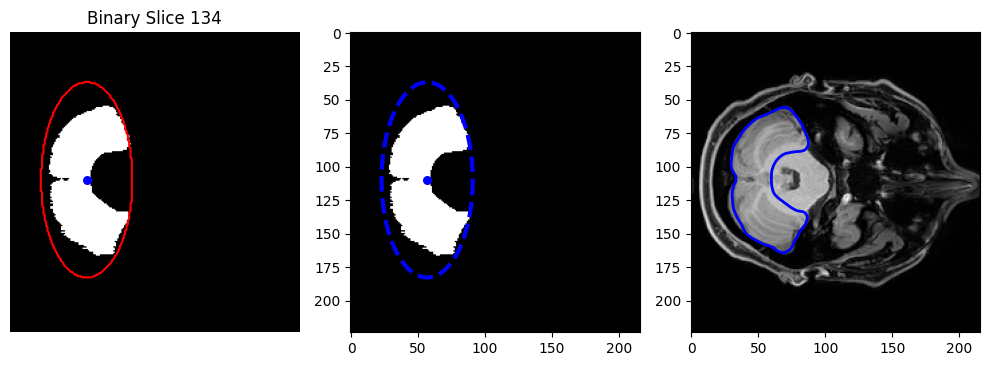

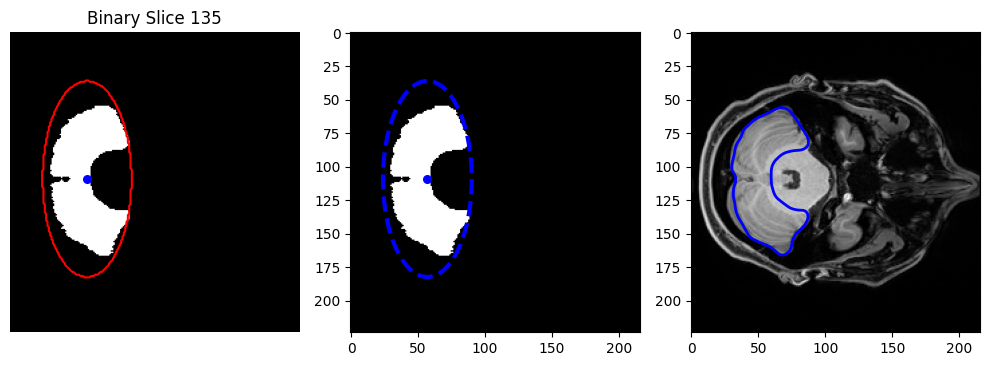

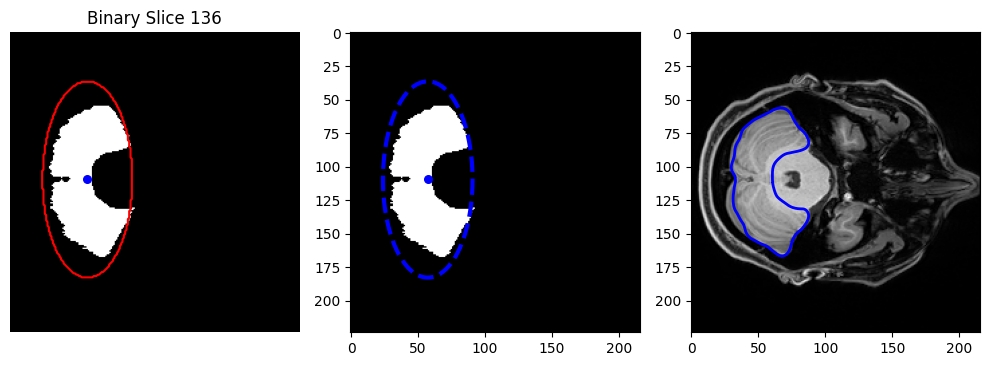

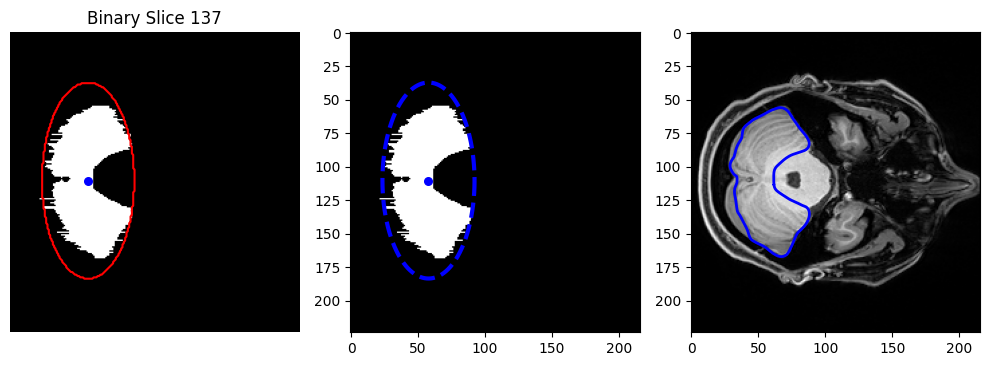

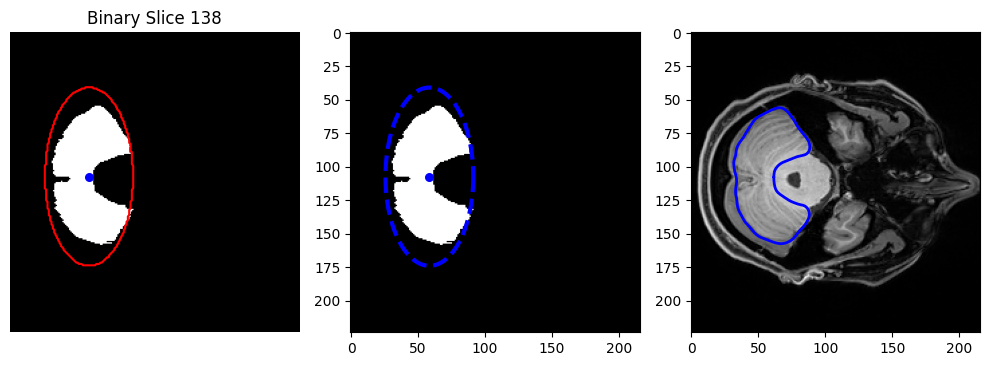

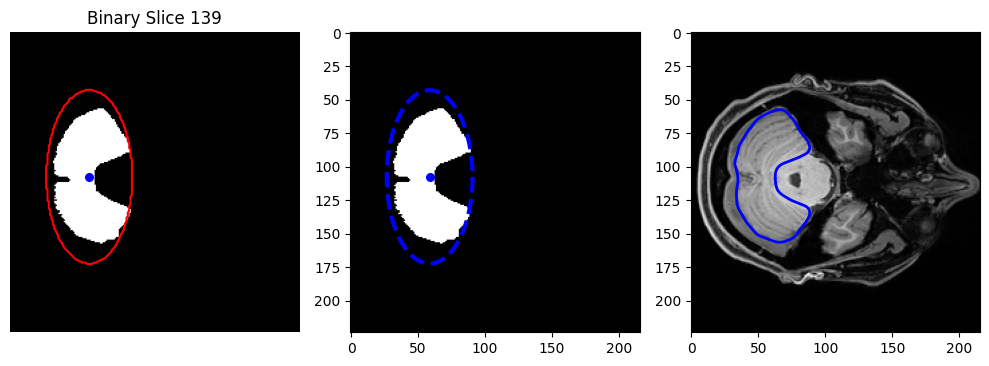

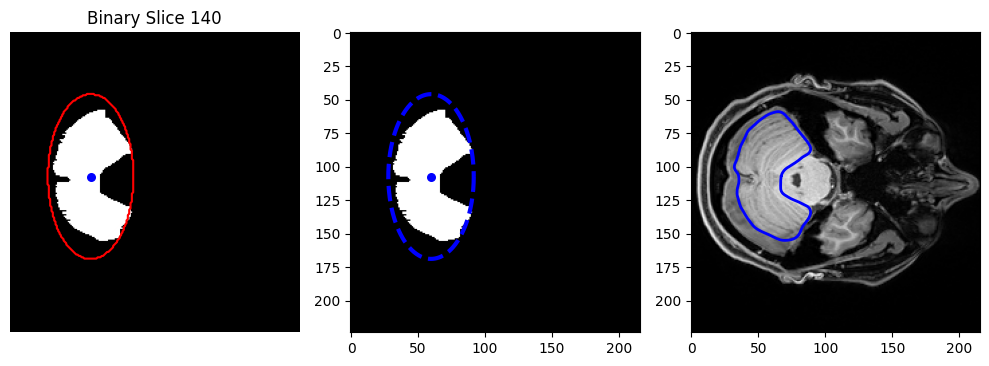

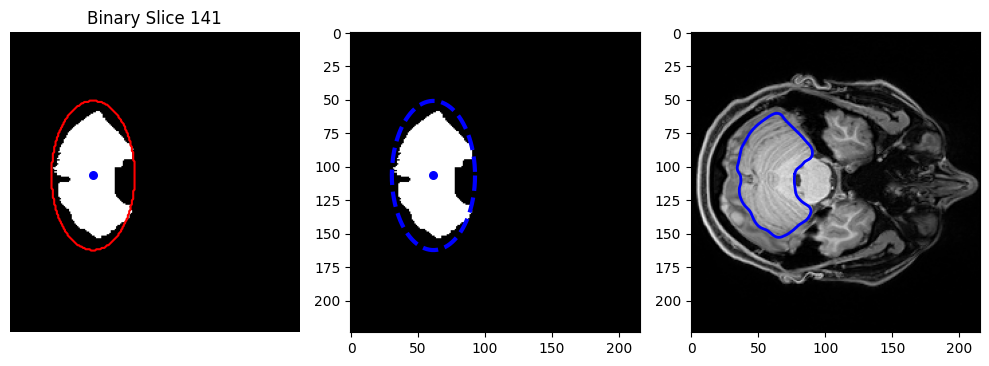

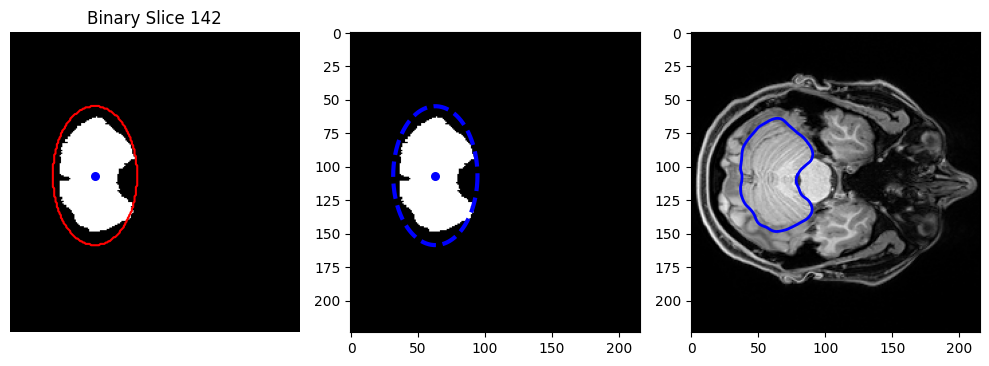

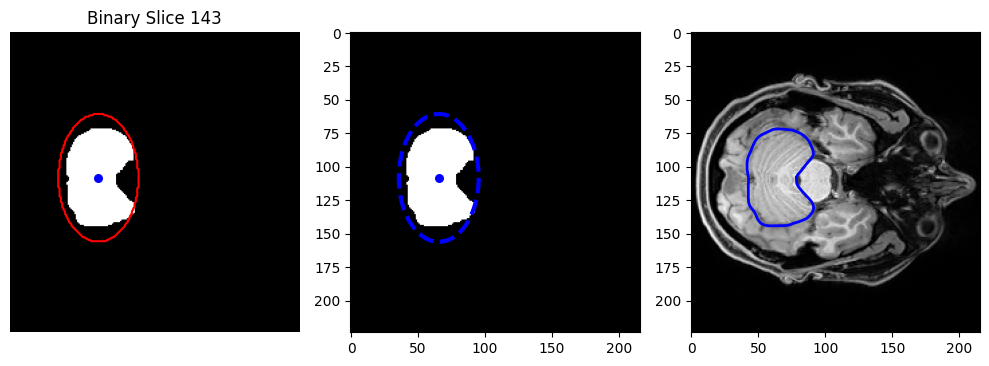

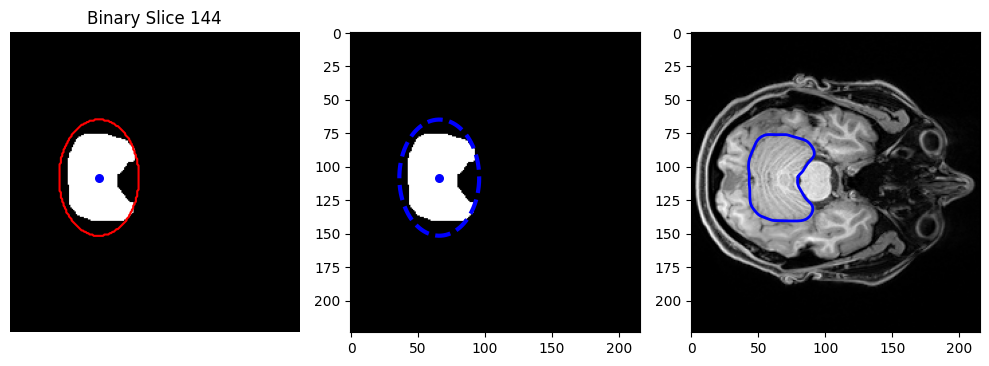

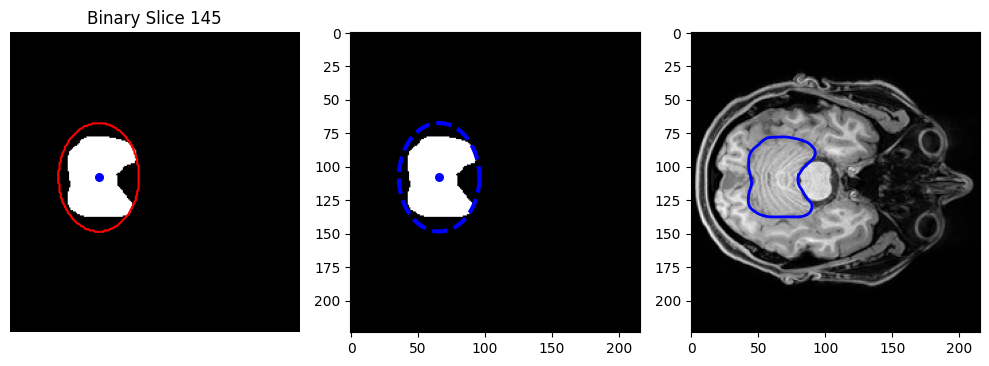

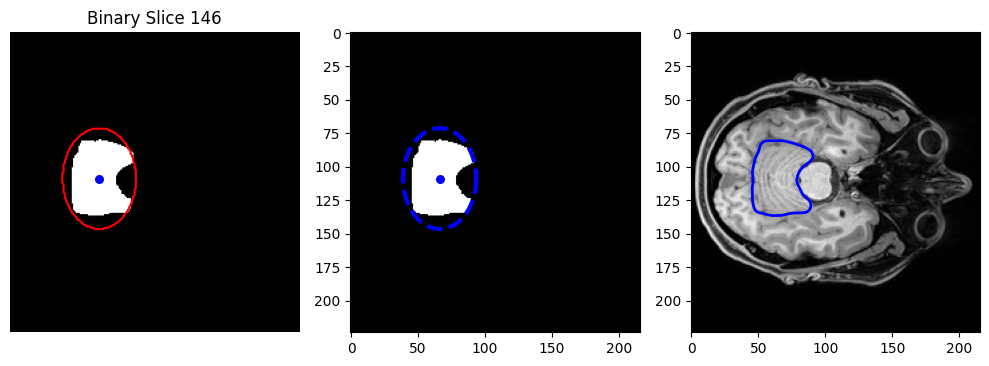

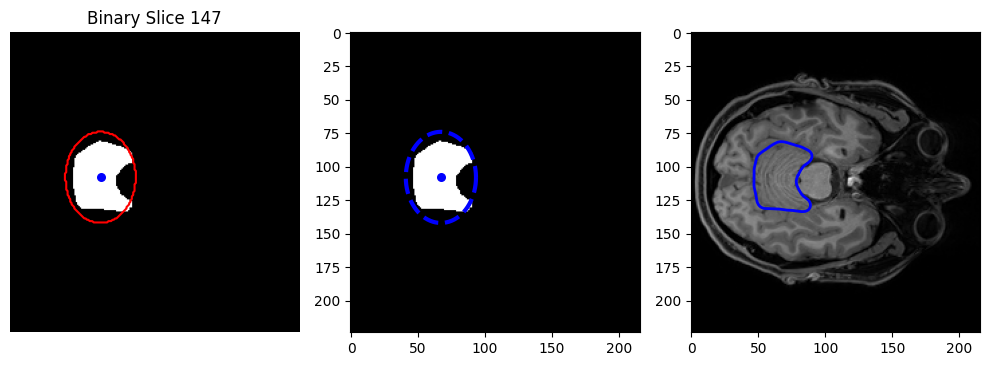

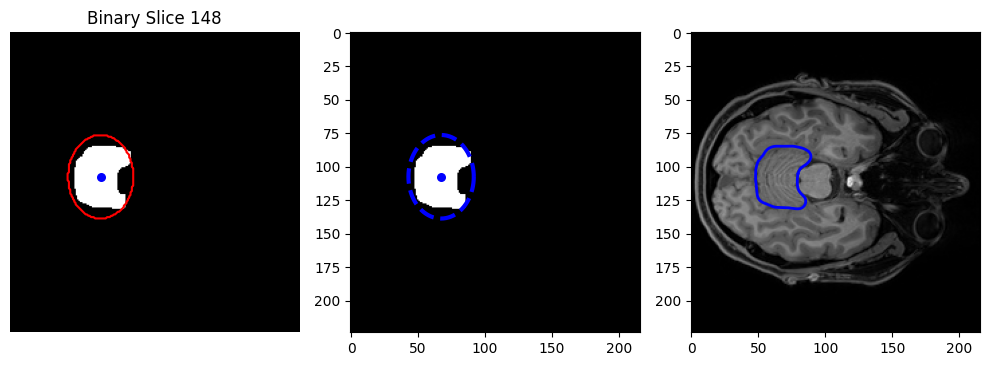

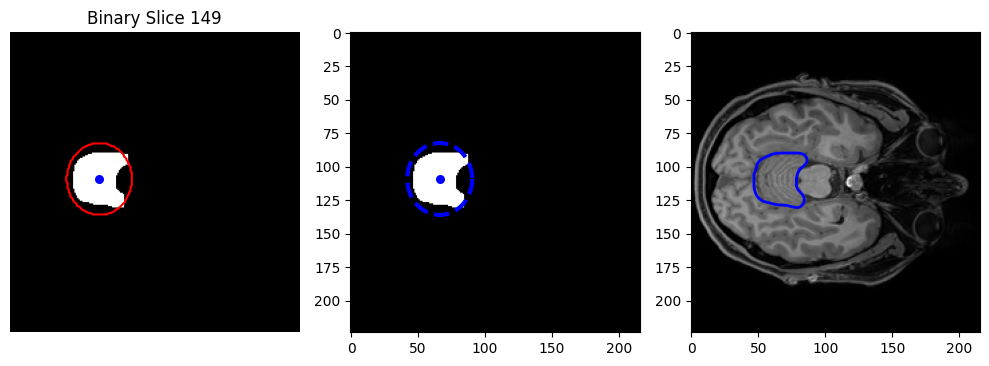

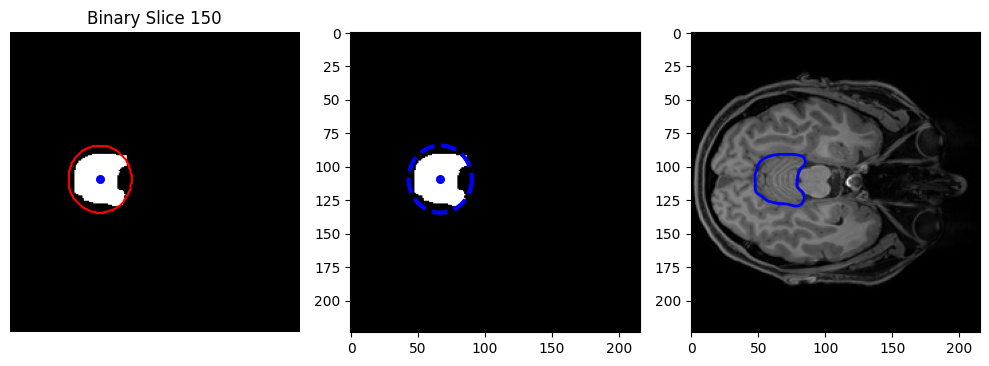

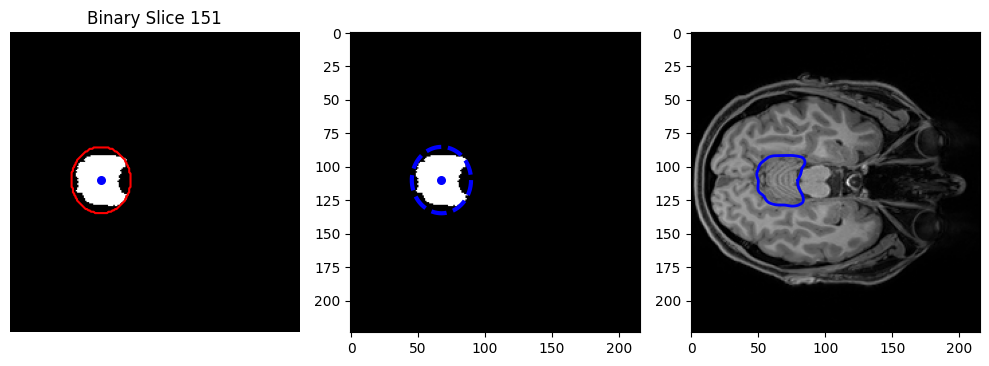

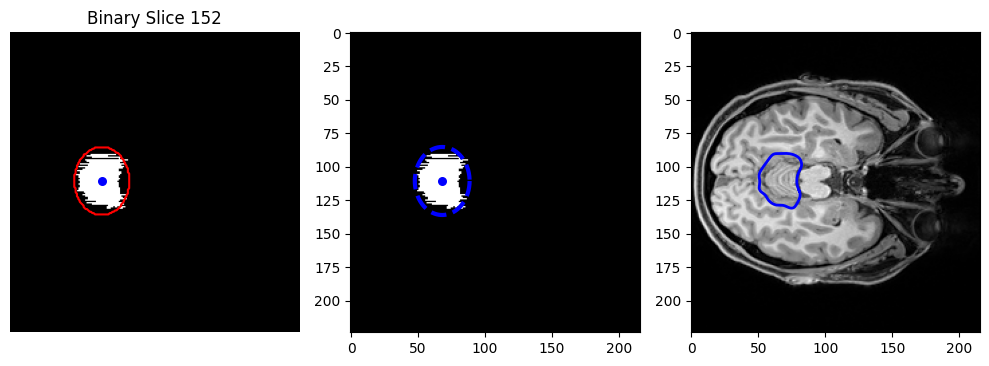

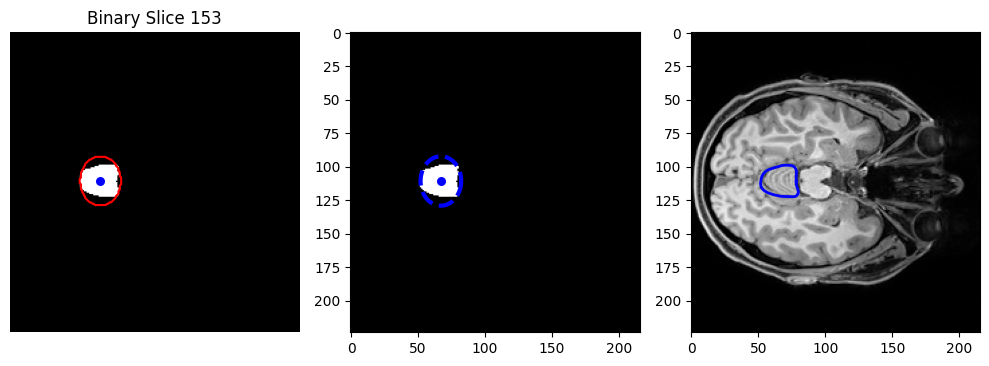

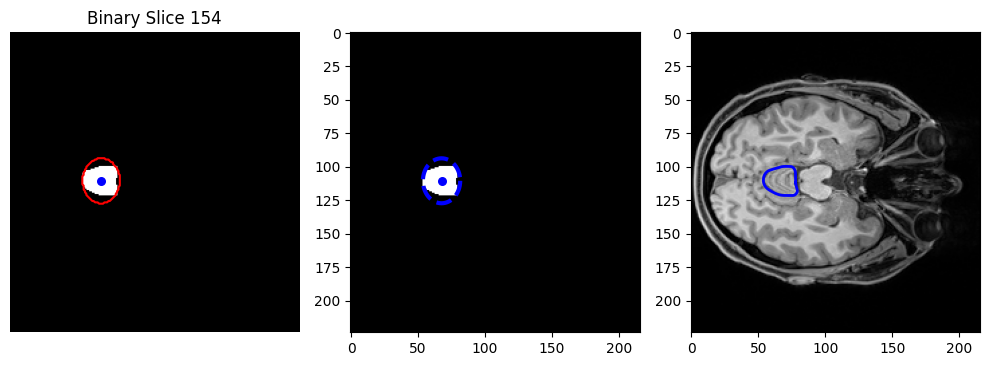

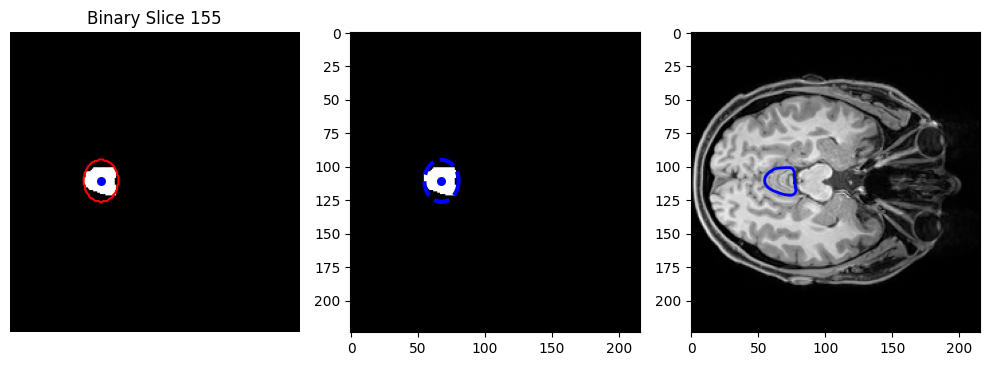

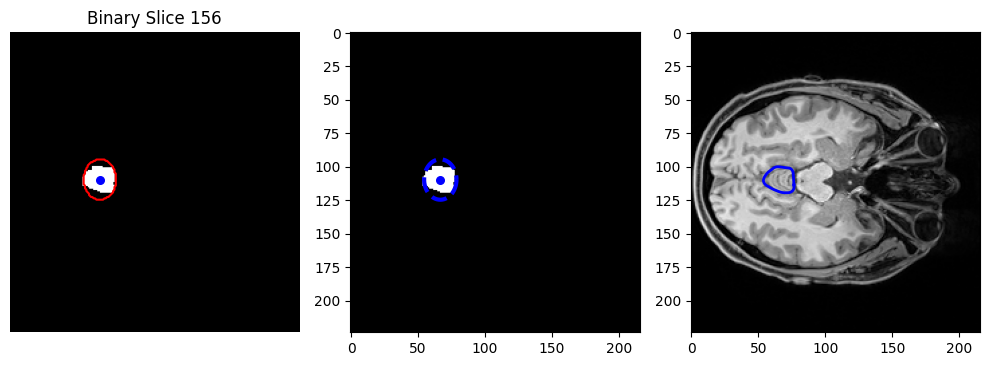

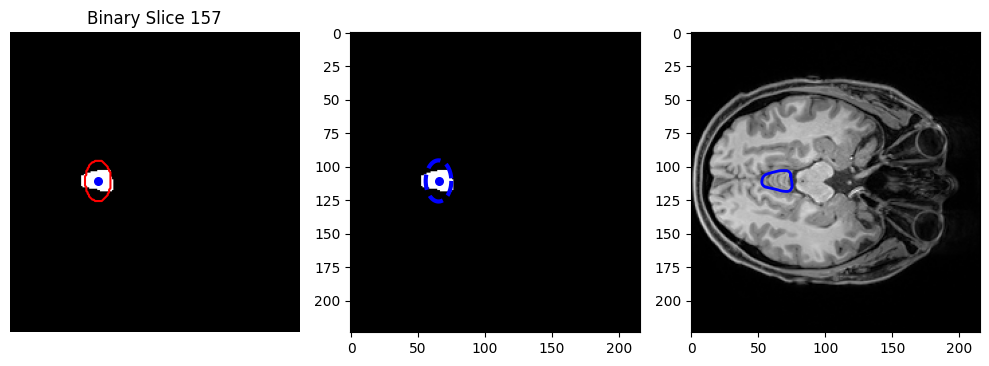

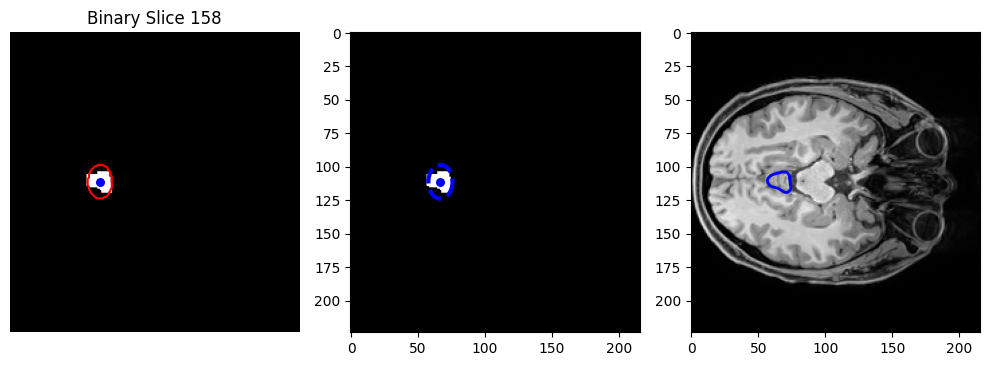

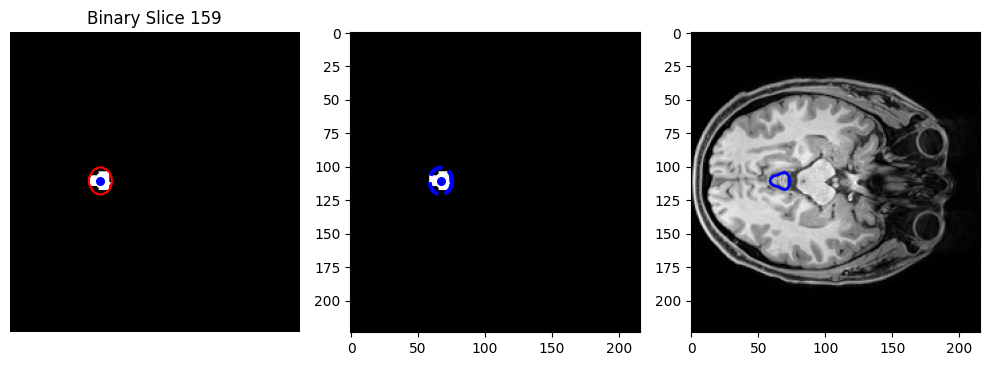

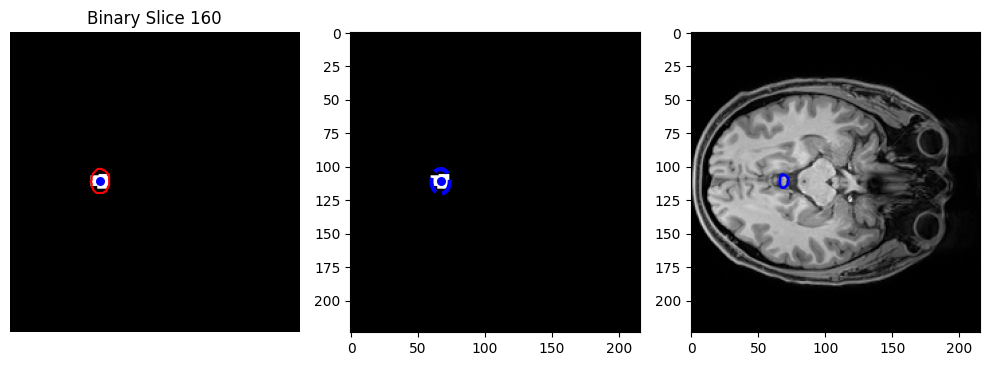

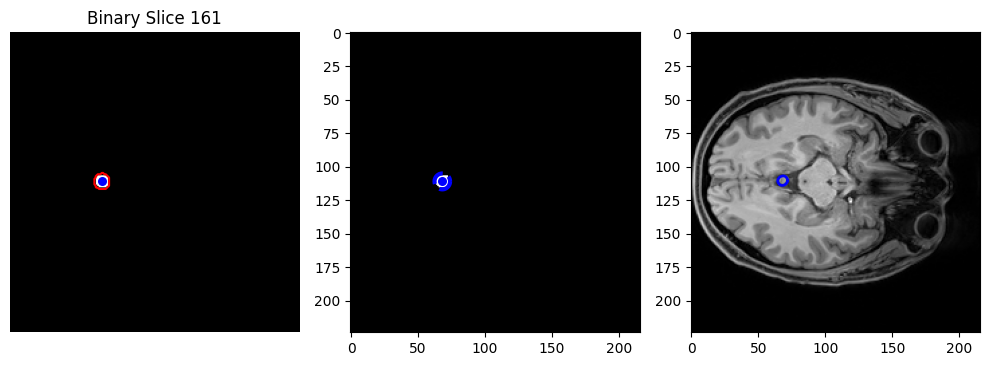

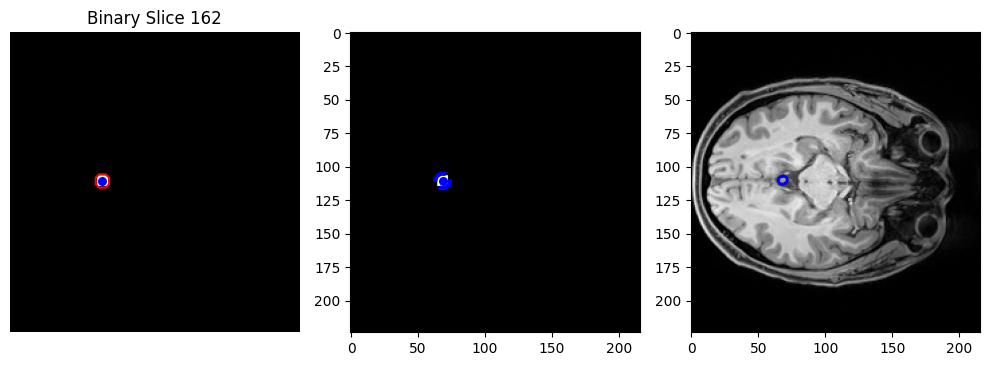

[[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 ...

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False Fal

In [4]:
# DRAW THE SNAKE FOR EVERY SLICE
from skimage.measure import regionprops
from skimage.filters import gaussian
from skimage.draw import polygon2mask
from skimage.segmentation import inverse_gaussian_gradient, active_contour
snake_masks = []
for slice_idx in slices_with_cerebellum:
    props = regionprops(labeled[:,:,slice_idx])
    y0 = props[0].centroid[0]
    x0 = props[0].centroid[1]
    major_axis_length = props[0].major_axis_length * 1.2
    minor_axis_length = props[0].minor_axis_length * 1.2

    ratio = 0.99
    # vertical semiax
    radius1 = (major_axis_length / 2.0) * ratio
    # horizontal semiax
    radius2 = (minor_axis_length / 2.0) * ratio

    #around what to put the ellyps
    tmp = vol_binary[:,:,slice_idx]
    h,w = tmp.shape
    Y,X = np.ogrid[:h,:w]
    init_ls = (((Y - y0)**2) / radius1**2 + ((X - x0)**2) / radius2**2) <= 1
    init_ls = init_ls.astype(float)

    # show also the dots 
    s = np.linspace(0, 2 * np.pi, 400)
    r = y0 + radius1 * np.sin(s)
    c = x0 + radius2 * np.cos(s)
    init_pts = np.column_stack((r, c))



    # take the normal slice
    img_slice = vol_mri[:,:,slice_idx]
    mask = vol_binary[:, :, slice_idx].astype(bool)
    img_masked = img_slice.copy()
    img_masked[~mask] = 0

    #apply the guassian filter
    img_f = gaussian(img_masked, sigma=2, preserve_range=False)
    snake = active_contour(
        img_f,
        init_pts,
        alpha=50,
        beta = 50,
        gamma = 50,
        w_edge = 1.5
    )
    slice_shape = img_f.shape
    snake_mask = polygon2mask(slice_shape, snake)
    snake_masks.append(snake_mask)

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(tmp,cmap='gray')
    axes[0].contour(init_ls, [0.5], colors='r')
    axes[0].scatter([x0], [y0], c='b', s=30)
    axes[0].set_title(f"Binary Slice {slice_idx}")
    axes[0].axis('off')

    axes[1].imshow(tmp,cmap='gray')
    axes[1].plot(init_pts[:,1],init_pts[:,0],'--b',lw=3)
    axes[1].scatter([x0], [y0], c='b', s=30)

    axes[2].imshow(vol_mri[:,:,slice_idx], cmap='gray')
    axes[2].plot(snake[:,1], snake[:,0], 'b-',  lw=2)


    plt.tight_layout()
    plt.show()

masks_volume = np.stack(snake_masks, axis=2)
print(masks_volume)


NOW LET'S EXTRACT THE WM FROM THE CEREBELLUM

In [9]:
import os, subprocess
import cv2

# Assume vol_sub and mask_sub are already shaped (H, W, N), and the background has been zeroed
# First, compute a minimal bounding box and crop vol_sub & mask_sub to the smallest rectangle
vol_sub  = vol_mri[:, :, slices_with_cerebellum] * masks_volume

# 1) Find the x, y range of all True points in the mask
ys, xs, zs = np.nonzero(masks_volume)
y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

# 2) Crop the volume
vol_crop = vol_sub[y0:y1, x0:x1, :]
vol_orig = vol_crop.copy()

# 2.5) Optimized enhancement: reduce highlights/shadows + emphasize white texture
enh = np.empty_like(vol_crop, dtype=np.float64)

for z in range(vol_crop.shape[2]):
    img = vol_crop[..., z].astype(np.float32)

    # —— 1) Normalize to [0,1] ——
    mn, mx = img.min(), img.max()
    if mx > mn:
        norm = (img - mn) / (mx - mn)
    else:
        norm = img * 0.0

    # —— 2) Gamma correction: brighten highlights (gamma < 1) ——
    gamma = 0.8
    norm = np.power(norm, gamma)

    # —— 3) CLAHE: local contrast enhancement ——
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img8 = np.uint8((norm * 255).clip(0, 255))
    cl = clahe.apply(img8) / 255.0  # Restore to [0,1]

    # —— 4) Unsharp mask: sharpen details ——
    blurred = cv2.GaussianBlur(cl, (0, 0), sigmaX=1.0)
    sharp = cl + 1.5 * (cl - blurred)
    sharp = np.clip(sharp, 0, 1)

    # —— 5) Restore to original dynamic range ——
    enh[..., z] = sharp * (mx - mn) + mn

# 2.5.5) Write back to vol_crop, preserving float64 type & same dimensions
vol_crop = enh

# 3) Save as NIfTI
affine = np.eye(4)
nib.save(nib.Nifti1Image(vol_crop, affine), 'T1_crop.nii.gz')

# 4) Configure FSL
os.environ['FSLDIR']         = '/Users/enricotuda/fsl'
os.environ['PATH']           = os.path.join(os.environ['FSLDIR'], 'bin') + ':' + os.environ['PATH']
os.environ['FSLOUTPUTTYPE']  = 'NIFTI_GZ'


In [10]:
from skimage.filters import hessian

# assume `vol_sub` is your (H,W,D) subvolume and `affine` is the 4×4 affine you want to use

H, W, D = vol_sub.shape

# 1) allocate an empty volume to hold Hessian responses
hess_vol = np.zeros_like(vol_sub, dtype=np.float32)

# 2) loop over slices, compute Hessian, store
for z in range(D):
    img = vol_sub[:, :, z]
    # NOTE: hessian returns a float image same shape as input
    hess_slice = hessian(img, sigmas=[1])
    hess_vol[:, :, z] = hess_slice


affine = np.eye(4)
hess_img = nib.Nifti1Image(hess_vol, affine)


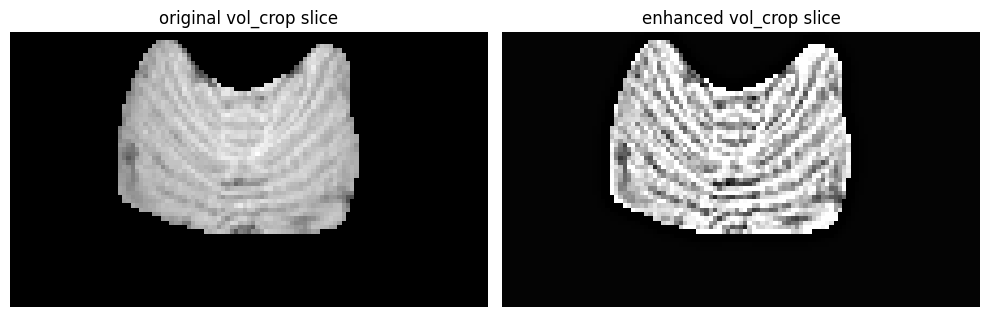

In [11]:
# print a slice, for demonstration
slice_idx = 40
orig_slice = vol_orig[:, :, slice_idx]
proc_slice = vol_crop[:, :, slice_idx]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.rot90(orig_slice), cmap='gray')
axes[0].set_title('original vol_crop slice')
axes[0].axis('off')

axes[1].imshow(np.rot90(proc_slice), cmap='gray')
axes[1].set_title('enhanced vol_crop slice')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# 5) Run FAST on cropped volume

FAST = os.path.join(os.environ['FSLDIR'], 'bin', 'fast')
subprocess.run([
    FAST,
    '-t', '1',          # T1 mode
    '-n', '5',          # 5-class segmentation: CSF / GM / WM
    '-I', '6',          # Bias field correction: number of iterations
    '-l', '10',         # MRF smoothing; the higher, the smoother
    '-H', '0.1',        # Higher values give smoother boundaries
    '-o', 'fast_crop',  # Output file prefix
    'T1_crop.nii.gz'    # NIfTI file to be segmented
], check=True)

# 6) Load the segmentation result and pad it back to the original volume size
seg_crop = nib.load('fast_crop_seg.nii.gz').get_fdata().astype(int)
Hc, Wc, _ = vol_crop.shape
H, W, N = vol_sub.shape

seg_sub = np.zeros((H, W, N), int)
seg_sub[y0:y1, x0:x1, :] = seg_crop

# 7) Final white_volume
white_volume = (seg_sub == 5) & masks_volume
print("white_volume.shape =", white_volume.shape)


white_volume.shape = (224, 216, 57)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.morphology import binary_opening,binary_erosion
for i, slice_idx in enumerate(slices_with_cerebellum):
    img        = vol_mri[:, :, slice_idx]
    cereb_mask = masks_volume[:, :, i]
    wm_mask    = white_volume[:, :, i]

    # 1) Original image cropped by cerebellum mask
    img_cereb = img.copy()
    img_cereb[~cereb_mask] = 0

    # 2) Original image cropped by white matter mask (not used in overlay, for display only)
    img_wm = img.copy()
    img_wm[~wm_mask] = 0
    
    wm_mask = remove_small_objects(wm_mask,min_size=50,connectivity=1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Original image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Slice {slice_idx}\nOriginal")
    axes[0].axis('off')

    # Cropped cerebellum mask
    axes[1].imshow(img_cereb, cmap='gray')
    axes[1].set_title("Cerebellum Cropped")
    axes[1].axis('off')

    # White matter mask
    axes[2].imshow(wm_mask, cmap='gray')
    axes[2].set_title("White Matter Mask")
    axes[2].axis('off')

    # Overlay: red WM regions over cerebellum image
    axes[3].imshow(img_cereb, cmap='gray')  # Base image: cerebellum
    # Overlay in red: WM areas appear in red, alpha controls transparency
    red_only = ListedColormap([
        (0, 0, 0, 0),   # RGBA: transparent
        (1, 0, 0, 1),   # RGBA: pure red
    ])
    axes[3].imshow(wm_mask, cmap=red_only, alpha=0.5)
    axes[3].set_title("WM Overlay on Cerebellum")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) WM only in the cropped sub-volume
img_wm = np.where(white_volume, vol_sub, 0)  # shape matches (224,216,59)

# 2) Plot every slice in one tall column
H, W, D = img_wm.shape
fig, axes = plt.subplots(D, 1, figsize=(6, 3*D), squeeze=False)

for i in range(D):
    ax = axes[i,0]
    ax.imshow(img_wm[:,:,i], cmap='gray')
    ax.axis('off')
    ax.set_title(f"WM only — slice {i}")

plt.tight_layout()
plt.show()

In [ ]:
# I have the wm in img_wm
# Service functions

from mpl_toolkits.axes_grid1 import make_axes_locatable

# simplify our life for adding colorbars
def add_colorbar(ax,im,fig):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="5%", pad=0.25)
    fig.colorbar(im,  cax=cax, orientation='horizontal')
    
def show_images(img_to_show,slices_to_show):
    n_slices_to_show = len(slices_to_show)
    fig, ax = plt.subplots(1,n_slices_to_show, figsize=(20,6))
    for i in range(n_slices_to_show):
        ax[i].imshow(img_to_show[:,:,slices_to_show[i]])
        ax[i].set_title(str(slices_to_show[i]))
    plt.show()
    

def show_images_with_colorbar(img_to_show,slices_to_show,figsize=(20,7)):
    n_slices_to_show = len(slices_to_show)
    fig, ax = plt.subplots(1,n_slices_to_show, figsize=figsize)
    for i in range(n_slices_to_show):
        im = ax[i].imshow(img_to_show[:,:,slices_to_show[i]])
        ax[i].set_title(str(slices_to_show[i]))
        add_colorbar(ax[i],im,fig)
    plt.show()



In [ ]:
from scipy.ndimage import gaussian_filter
# generation of the gaussian of the Laplacian
sigma = 1.3
# eigenvalues
d_xx = gaussian_filter(img_wm, sigma=sigma, order=(2,0,0))
d_yy = gaussian_filter(img_wm, sigma=sigma, order=(0,2,0))
d_zz = gaussian_filter(img_wm, sigma=sigma, order=(0,0,2))

laplacian = d_xx + d_yy + d_zz

In [ ]:

fig, ax = plt.subplots(1,3,figsize=(20,20))

clim = np.percentile(np.abs(laplacian.flatten()),99)

im = ax[0].imshow(laplacian[100,:,:].T[::-1,:],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[0],im,fig)
ax[0].set_title('Laplacian (Sagittal)')
im = ax[1].imshow(laplacian[:,70,:].T[::-1,:],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[1],im,fig)
ax[1].set_title('Laplacian (Coronal)')
ax[2].imshow(laplacian[:,:,30].T[::-1,::-1],cmap='PuOr',clim=(-clim,clim))
add_colorbar(ax[2],im,fig)
ax[2].set_title('Laplacian (Axial)')


laplacian.shape

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
import structure_tensor as st

# --- STEP 4: MULTI-SCALE FA ON WHITE MATTER ONLY & BEST-SIGMA MAP ---
# Define the list of scales (sigma values) to test
sigmas = [0.5, 1.0, 1.5, 2.0]

# Assume vol_sub is your cropped cerebellum volume (H, W, D)
# white_volume is the boolean mask of white matter in vol_sub

# Create a masked volume containing only white matter
vol_wm = vol_sub.copy()
vol_wm[~white_volume] = 0.0

H, W, D = vol_wm.shape

# Initialize FA_max and best_sigma arrays
FA_max     = np.zeros((H, W, D), dtype=np.float32)
best_sigma = np.zeros((H, W, D), dtype=np.float32)

# Loop over each sigma to compute FA at that scale (white matter only)
for s in sigmas:
    # Compute diagonal Hessian components at scale s on vol_wm
    Hxx = gaussian_filter(vol_wm, sigma=s, order=(2,0,0))
    Hyy = gaussian_filter(vol_wm, sigma=s, order=(0,2,0))
    Hzz = gaussian_filter(vol_wm, sigma=s, order=(0,0,2))

    # Compute FA_s from these Hessian channels
    lam1 = np.abs(Hxx)
    lam2 = np.abs(Hyy)
    lam3 = np.abs(Hzz)
    mu   = (lam1 + lam2 + lam3) / 3.0
    numer = np.sqrt((lam1 - mu)**2 + (lam2 - mu)**2 + (lam3 - mu)**2)
    denom = np.sqrt(lam1**2 + lam2**2 + lam3**2) + 1e-12
    FA_s  = np.sqrt(1.5) * (numer / denom)

    # Update FA_max and best_sigma where FA_s is greater
    mask = FA_s > FA_max
    FA_max[mask]     = FA_s[mask]
    best_sigma[mask] = s

# After loop:
# FA_max[x,y,z]    = maximum FA over white matter for each voxel
# best_sigma[x,y,z] = sigma that achieved that maximum

In [ ]:
# --- STEP 5: COMPUTE DIRECTION AT BEST-SIGMA (3D STRUCTURE TENSOR) ---
# rho for ST smoothing
rho = 0.05
# precompute orientation fields for each sigma
orientation_3d = {}
for s in sigmas:
    # 3D gradients
    Ix = gaussian_filter(vol_wm, sigma=s, order=(1,0,0))
    Iy = gaussian_filter(vol_wm, sigma=s, order=(0,1,0))
    Iz = gaussian_filter(vol_wm, sigma=s, order=(0,0,1))
    # ST components
    Jxx = gaussian_filter(Ix*Ix, sigma=rho)
    Jyy = gaussian_filter(Iy*Iy, sigma=rho)
    Jzz = gaussian_filter(Iz*Iz, sigma=rho)
    Jxy = gaussian_filter(Ix*Iy, sigma=rho)
    Jxz = gaussian_filter(Ix*Iz, sigma=rho)
    Jyz = gaussian_filter(Iy*Iz, sigma=rho)
    # allocate vector field
    vecs = np.zeros((3, H, W, D), dtype=np.float32)
    # eigen-decompose each voxel
    for i in range(H):
        for j in range(W):
            for k in range(D):
                S = np.array([[Jxx[i,j,k], Jxy[i,j,k], Jxz[i,j,k]],
                              [Jxy[i,j,k], Jyy[i,j,k], Jyz[i,j,k]],
                              [Jxz[i,j,k], Jyz[i,j,k], Jzz[i,j,k]]])
                w, v = np.linalg.eigh(S)
                vecs[:,i,j,k] = v[:, np.argmax(w)]
    orientation_3d[s] = vecs

# assemble final direction field based on best_sigma
directions = np.zeros((3, H, W, D), dtype=np.float32)
for s in sigmas:
    sel = (best_sigma == s)
    directions[:, sel] = orientation_3d[s][:, sel]

# Now directions[:, x, y, z] is the 3D principal orientation vector at each voxel


In [ ]:
# --- STEP 6: CREATE RGB MAP AND VISUALIZE ---
# normalize and map to [0,1]
mag       = np.linalg.norm(directions, axis=0) + 1e-12
dirs_unit = directions / mag
rgb_volume = (dirs_unit + 1.0) / 2.0  # R<-x, G<-y, B<-z
# reshape to (H,W,D,3)
rgb_volume = np.transpose(rgb_volume, (1,2,3,0))
# mask non-WM (some questions here)
rgb_volume[~white_volume] = 0.0

# Visualization: composite 4-panel per slice
valid_slices = [z for z in range(D) if white_volume[:,:,z].any()]
for z in valid_slices:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    # (1) Original
    axes[0].imshow(vol_sub[:,:,z], cmap='gray');    axes[0].axis('off'); axes[0].set_title(f'Orig {z}')
    # (2) Orig + WM overlay
    axes[1].imshow(vol_sub[:,:,z], cmap='gray')
    wm = white_volume[:,:,z]
    axes[1].imshow(wm, cmap=ListedColormap([(0,0,0,0),(1,0,0,0.5)])); axes[1].axis('off'); axes[1].set_title('Orig+WM')
    # (3) WM mask
    axes[2].imshow(wm, cmap='gray');                axes[2].axis('off'); axes[2].set_title('WM mask')
    # (4) RGB orientation (WM only)
    axes[3].imshow(rgb_volume[:,:,z]);              axes[3].axis('off'); axes[3].set_title('RGB orient')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- STEP 7: VISUALIZE BEST-SIGMA (SCALE) MAP FOR WM ONLY ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define discrete colors for each tested sigma
cmap = ListedColormap(["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"])
bounds = sigmas[:] + [sigmas[-1] + (sigmas[-1] - sigmas[-2])]  # e.g. [0.5,1.0,1.5,2.0,2.5]
norm = BoundaryNorm(bounds, cmap.N)

# Prepare masked sigma map (non-WM as NaN for white background)
best_sigma_masked = np.full_like(best_sigma, np.nan, dtype=np.float32)
best_sigma_masked[white_volume] = best_sigma[white_volume]

# Plot each slice
for idx in valid_slices:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    # Display with white background
    ax.set_facecolor('white')
    im = ax.imshow(best_sigma_masked[:, :, idx], cmap=cmap, norm=norm)
    ax.set_title(f'Best Sigma Slice {idx} (WM only)')
    ax.axis('off')
    # Create a discrete legend instead of gradient bar
    cbar = fig.colorbar(im, ax=ax, boundaries=bounds, ticks=sigmas, spacing='proportional', orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_ticklabels([str(s) for s in sigmas])
    plt.show()

# Optionally save as NIfTI:
# nib.save(nib.Nifti1Image(best_sigma_masked, img_mri.affine), 'best_sigma_map_wm.nii.gz')
